# 03 · Modeling & Evaluation

**Setup.** Episode-level 80/20 train/test split (`GroupShuffleSplit`) so no conversation spans the split. Hyper-parameters tuned with 5-fold `StratifiedGroupKFold` optimizing F1. Imbalance handled with SMOTE inside an `imblearn` pipeline (`StandardScaler → SMOTE → clf`). Baseline: a tuned threshold on `sim_to_current_query` (the similarity-retrieval incumbent).

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / 'src'))
import pandas as pd, numpy as np, json
from IPython.display import Image, display
PROC, RES, FIG = ROOT/'data'/'processed', ROOT/'results', ROOT/'reports'/'figures'


## Held-out test metrics (all models vs. similarity baseline)

In [2]:
m = pd.read_csv(RES/'metrics.csv', index_col=0); m.round(3)

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
SimilarityBaseline,0.698,0.266,0.466,0.339,0.633,0.286
LogisticRegression,0.696,0.312,0.689,0.429,0.767,0.396
kNN,0.634,0.282,0.777,0.414,0.750,0.370
DecisionTree,0.586,0.261,0.814,0.395,0.717,0.278
RandomForest,0.758,0.355,0.558,0.434,0.761,0.377
AdaBoost,0.721,0.323,0.620,0.425,0.758,0.373


## 5-fold cross-validated metrics (train)

In [3]:
pd.read_csv(RES/'cv_metrics.csv', index_col=0)[['cv_f1_mean','cv_f1_std','cv_roc_auc_mean','cv_precision_mean','cv_recall_mean']].round(3)

,cv_f1_mean,cv_f1_std,cv_roc_auc_mean,cv_precision_mean,cv_recall_mean
model,,,,,
LogisticRegression,0.426,0.012,0.777,0.305,0.708
kNN,0.385,0.013,0.747,0.259,0.755
DecisionTree,0.382,0.013,0.723,0.265,0.694
RandomForest,0.406,0.022,0.761,0.331,0.528
AdaBoost,0.421,0.020,0.767,0.321,0.612


## ROC and Precision-Recall curves

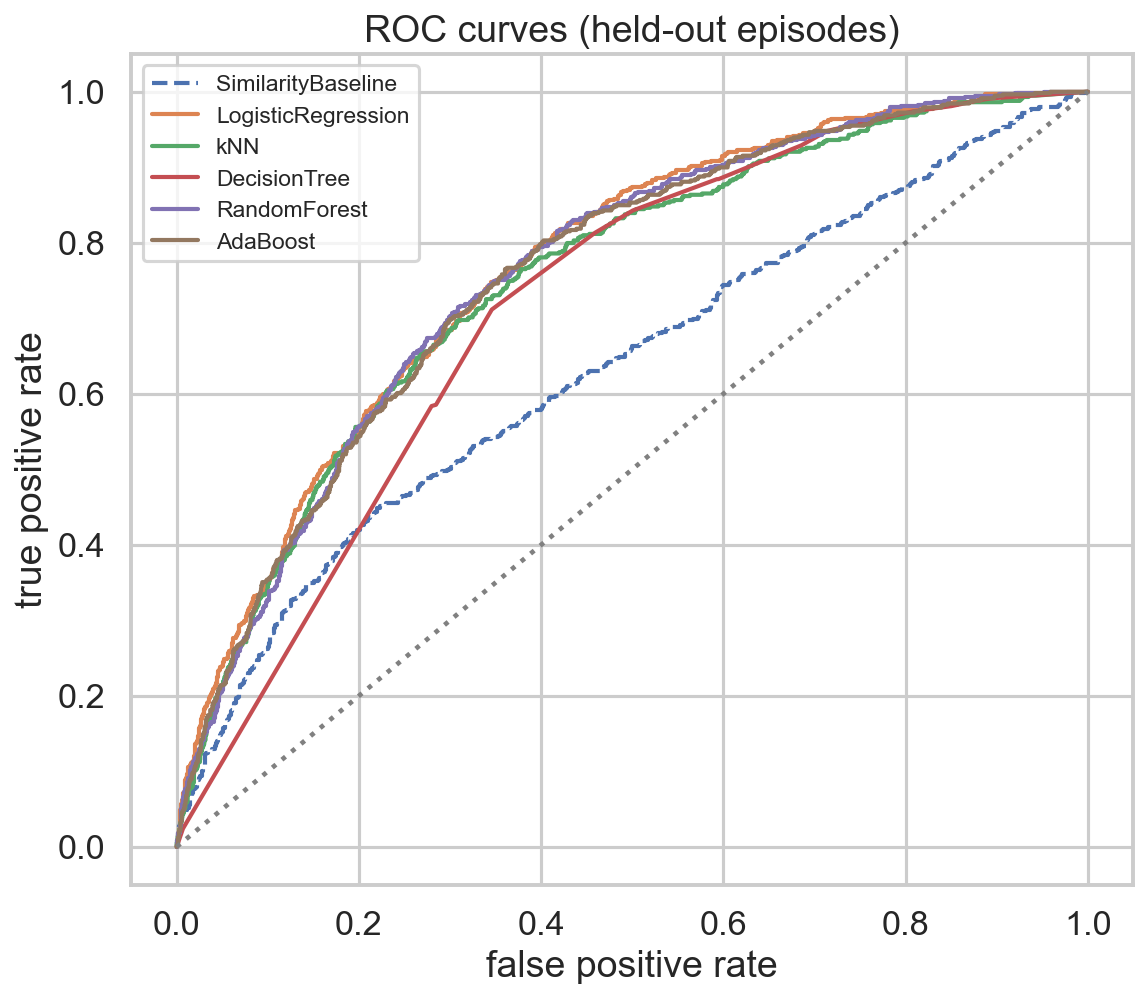

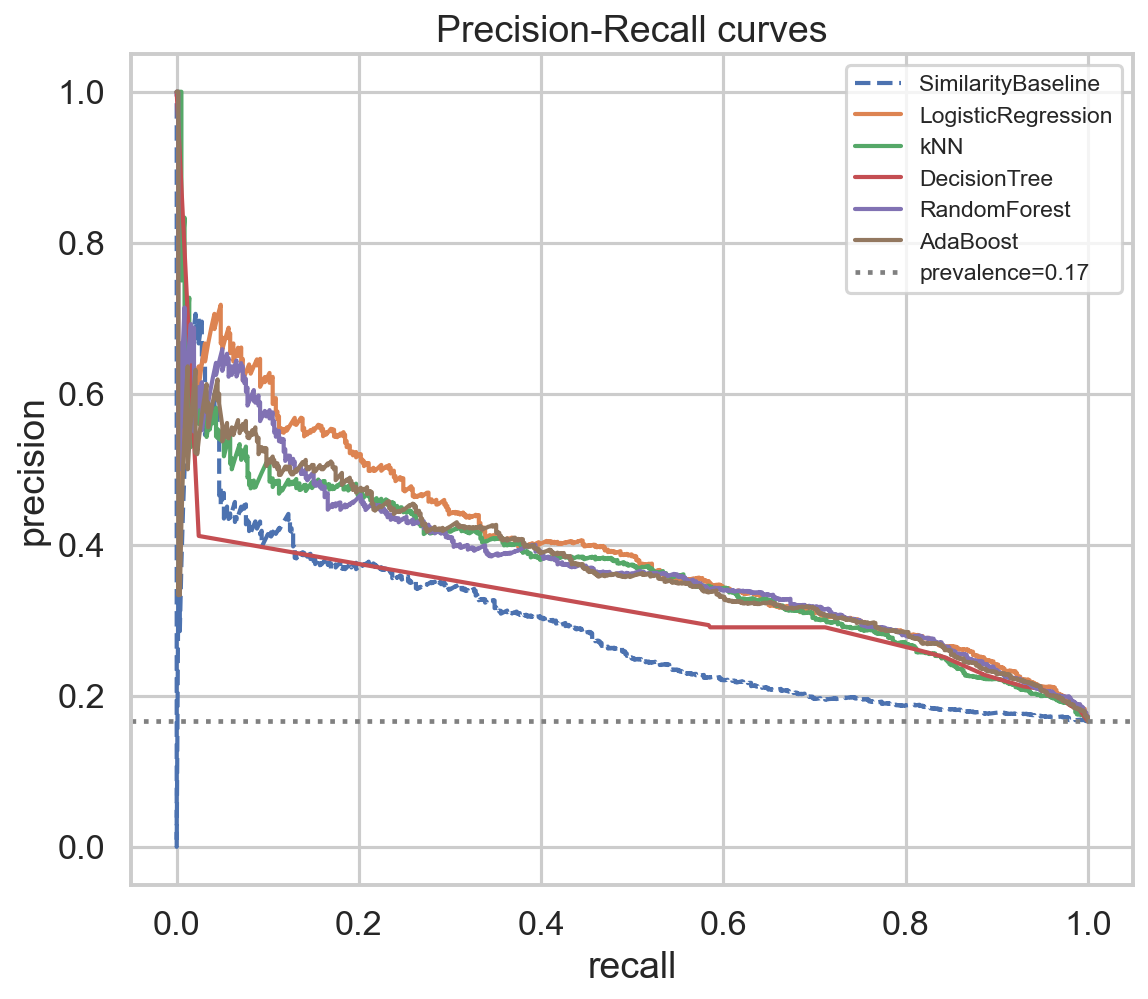

In [4]:
display(Image(str(FIG/'roc_curves.png')))
display(Image(str(FIG/'pr_curves.png')))

## Imbalance strategy ablation (best model)

SMOTE trades precision for a large recall gain — the right call when the goal is not to *lose* memories that matter.

In [5]:
pd.read_csv(RES/'imbalance_ablation.csv', index_col=0).round(3)

,accuracy,precision,recall,f1,roc_auc,pr_auc
strategy,,,,,,
none,0.838,0.544,0.159,0.246,0.770,0.401
smote,0.695,0.311,0.689,0.429,0.767,0.396
class_weight,0.699,0.314,0.686,0.431,0.770,0.400


## Confusion matrix, model comparison, and feature attributions

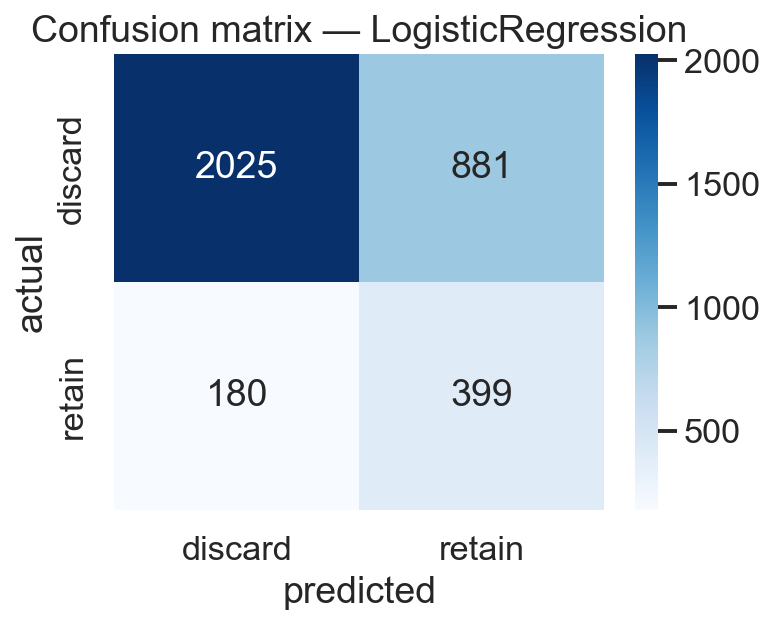

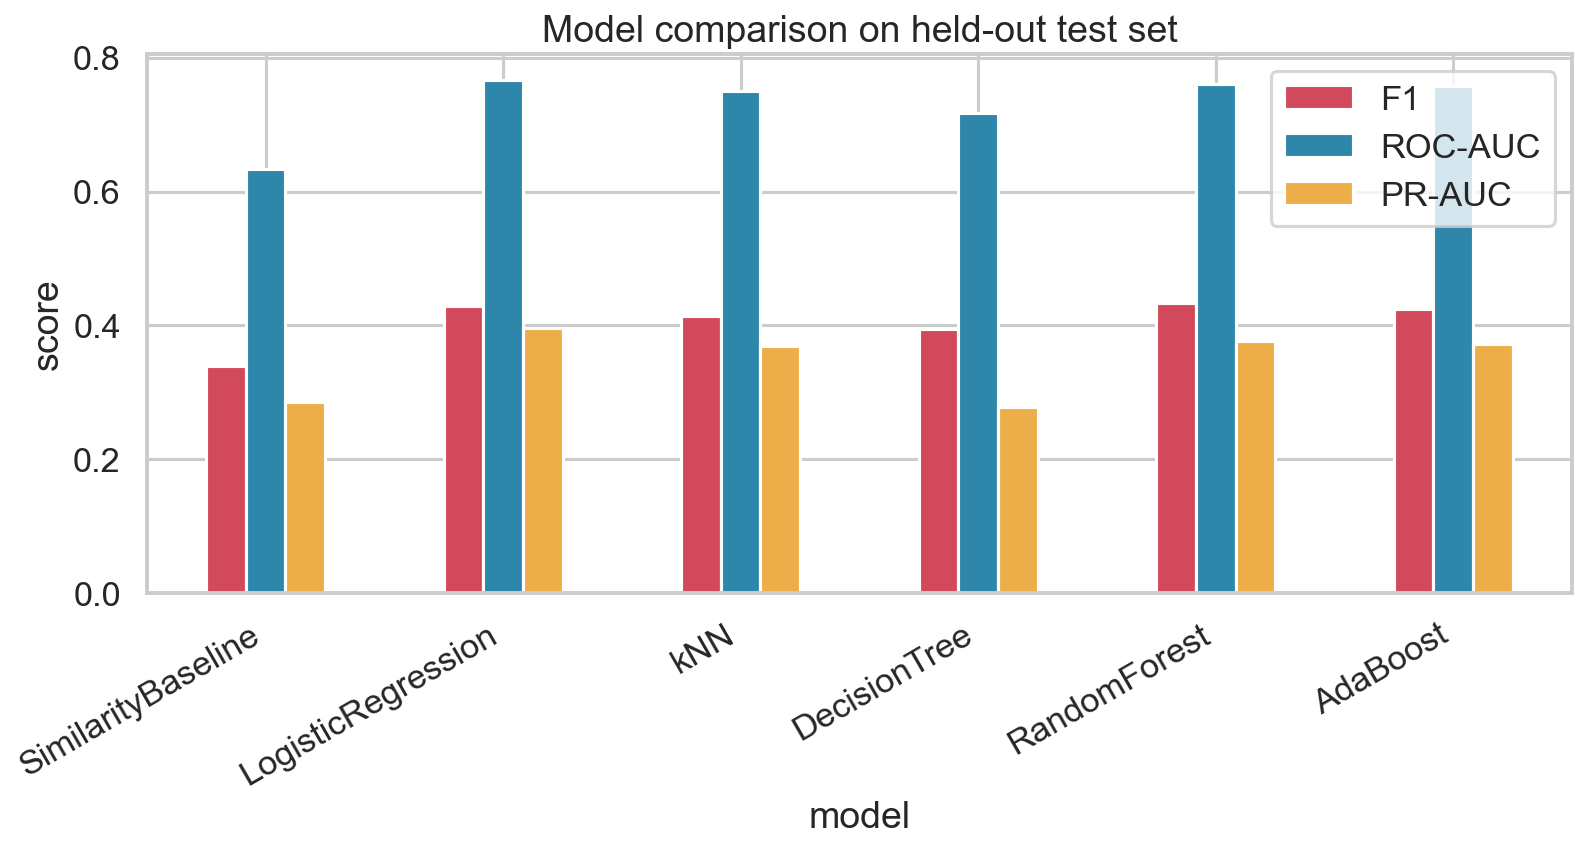

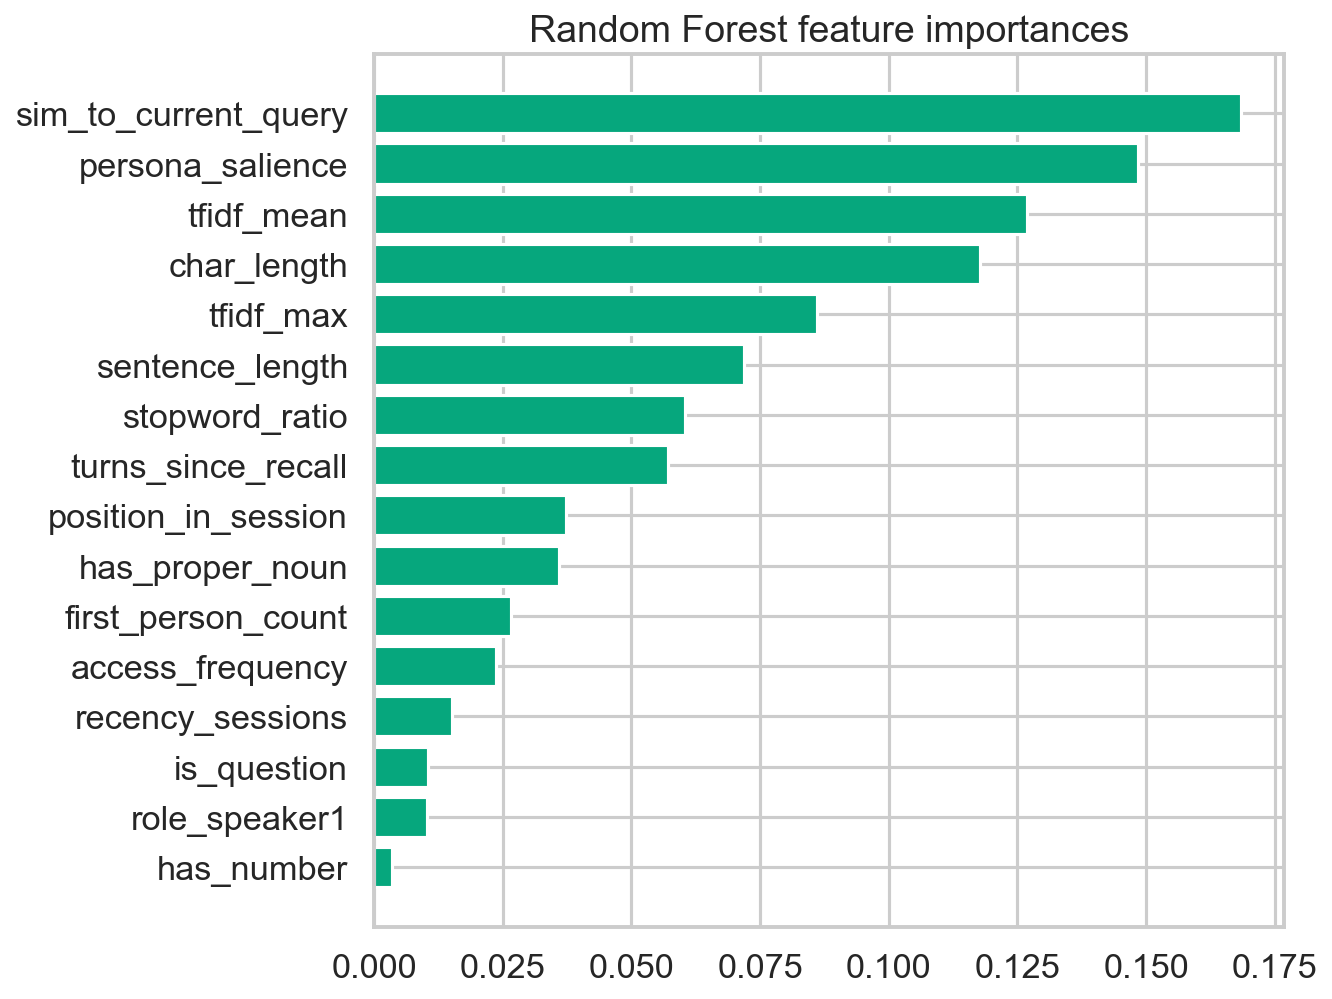

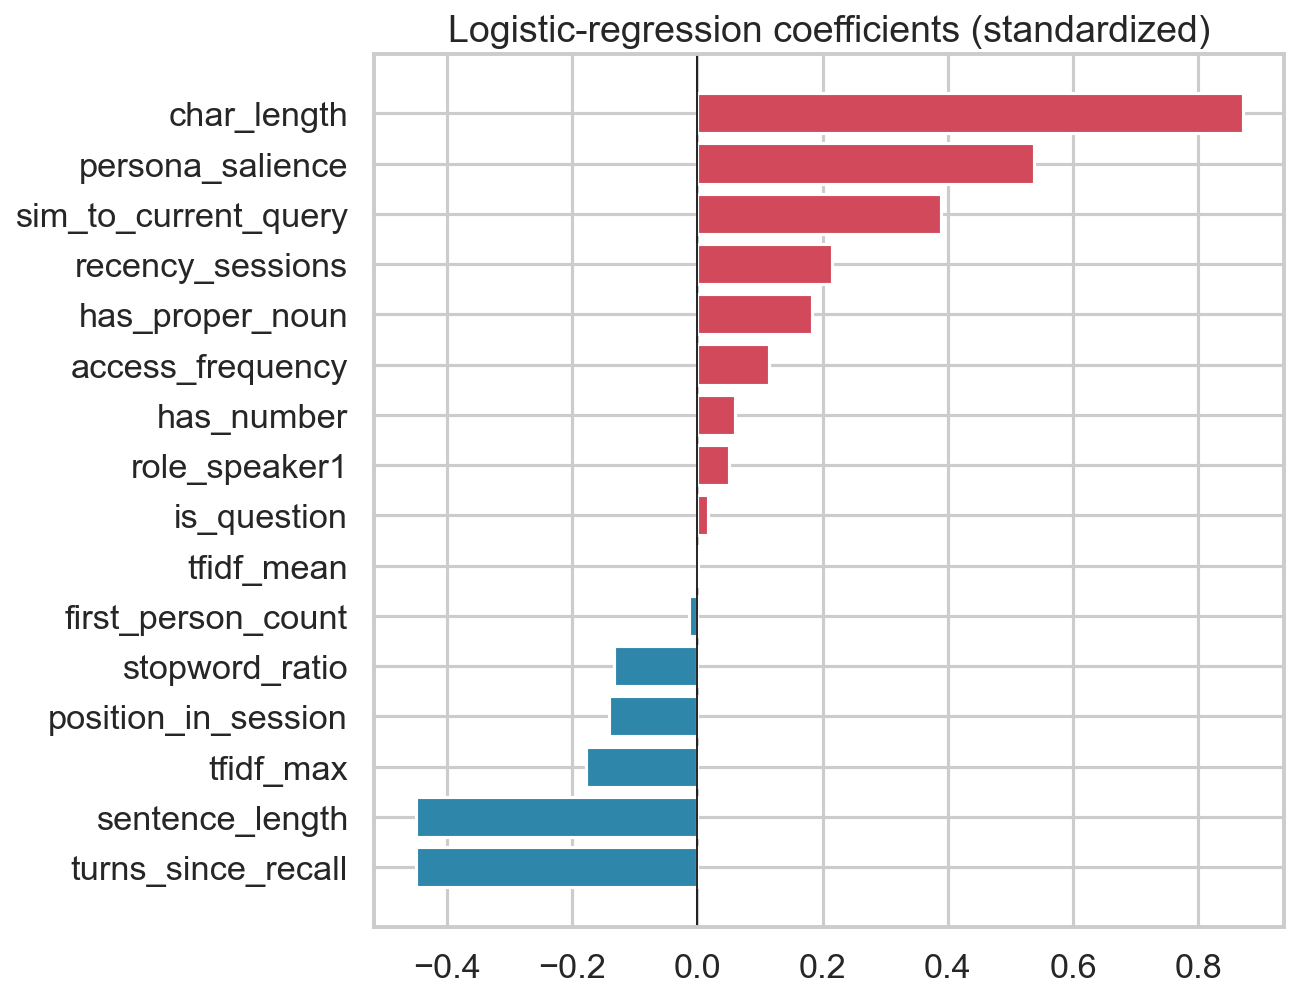

In [6]:
for f in ['confusion_matrix.png','model_comparison.png','feature_importance.png','logreg_coefficients.png']:
    display(Image(str(FIG/f)))

**Result.** Every supervised model beats the similarity baseline (ROC-AUC ≈ 0.77 vs 0.63; F1 ≈ 0.43 vs 0.34). We select the deployed model by **cross-validated** F1 (never the test set); that picks **Logistic Regression**, with Random Forest a near-equal alternative. Features capturing *specificity* and *persona-salience* — not raw query similarity — drive the gains. Note the imbalance ablation: SMOTE and class-weighting swing F1/recall sharply while PR-AUC stays ~0.40, i.e. they recalibrate the threshold, not the ranking.